In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)


import joblib


In [2]:
df = pd.read_csv("/Users/prerana/Documents/Banking_case/Banking_clean.csv")

In [3]:
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [5]:
product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Business Lending",
    "Foreign Currency Account",
    "Saving Accounts",
    "Checking Accounts"
]

df["Product_Count"] = df[product_cols].apply(lambda x: x.gt(0).sum(), axis=1)

In [6]:
df["Total_Financial_Value"] = (
    df["Superannuation Savings"] +
    df["Bank Deposits"] +
    df["Saving Accounts"] +
    df["Checking Accounts"] +
    df["Foreign Currency Account"] +
    df["Business Lending"] +
    df["Bank Loans"]
)

# Combine income + assets into one value metric
df["Customer_Value"] = df["Estimated Income"] + df["Total_Financial_Value"]

#RFM-Style Engagement Matrix

# Convert "Joined Bank" to datetime
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")

# Calculate recency as "years since joining"
today = pd.to_datetime("today")
df["Recency_Years"] = ((today - df["Joined Bank"]).dt.days) / 365

rfm_product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending"
]
# F: Frequency
# Count number of products actively used
df["Frequency"] = df[rfm_product_cols].gt(0).sum(axis=1)

#  M: Monetary
df["Monetary"] = df["Estimated Income"]


In [7]:
#Filling missing NaN with median
df.isnull().sum().sort_values(ascending=False)
#Numerical:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
#Categorical:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
y_reg = df["Customer_Value"]

In [11]:
# Tenure
current_year = 2026

df["Joined Bank"] = pd.to_datetime(
    df["Joined Bank"],
    errors="coerce"
)

df["Tenure"] = (
    current_year - df["Joined Bank"].dt.year
)

df["Tenure"] = df["Tenure"].fillna(
    df["Tenure"].median()
)

# Debt-to-Income Ratio
df["Debt_Income_Ratio"] = (
    df["Bank Loans"] /
    (df["Estimated Income"] + 1)
)

# Credit Utilization
df["Credit_Utilization"] = (
    df["Credit Card Balance"] /
    (df["Amount of Credit Cards"] + 1)
)

print(df[
    [
        "Tenure",
        "Debt_Income_Ratio",
        "Credit_Utilization"
    ]
].head())

   Tenure  Debt_Income_Ratio  Credit_Utilization
0     7.0          10.296942          242.270000
1    25.0           4.383922         1128.440000
2    15.0           6.194770         1522.913333
3    15.0           0.339664         1401.666667
4    15.0           8.019895         1889.745000


In [12]:
features_reg = [
    'Age',
    'Estimated Income',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Business Lending',
    'Risk Weighting',
    'Product_Count',
    'Frequency',
    'Monetary',
    'Recency_Years',
    'Tenure',
    'Debt_Income_Ratio',
    'Credit_Utilization'
]

X_reg = df[features_reg]

y_reg = df["Customer_Value"]

In [13]:
#Test/Train split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [14]:
#Scale features

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [15]:
#Regression Models
#Linear Regression

from sklearn.linear_model import LinearRegression

lr_reg_model = LinearRegression()

lr_reg_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

lr_reg_preds = lr_reg_model.predict(
    X_test_reg_scaled
)

In [16]:
#Random forest regressor

from sklearn.ensemble import RandomForestRegressor

rf_reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_reg_model.fit(
    X_train_reg,
    y_train_reg
)

rf_reg_preds = rf_reg_model.predict(
    X_test_reg
)

In [17]:
#Regression Matrix

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test_reg,
    rf_reg_preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_reg_preds
    )
)

r2 = r2_score(
    y_test_reg,
    rf_reg_preds
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 162433.83925787127
RMSE: 229009.37534838528
R2 Score: 0.9822712386897475


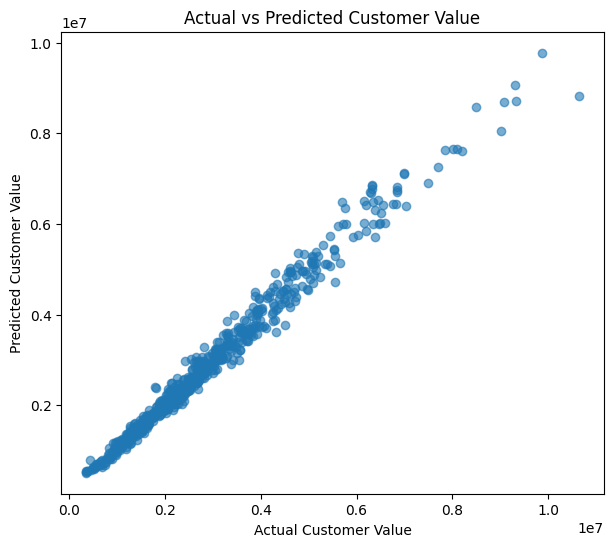

In [18]:
#Actual vs Predicted visualization

plt.figure(figsize=(7,6))

plt.scatter(
    y_test_reg,
    rf_reg_preds,
    alpha=0.6
)

plt.xlabel("Actual Customer Value")
plt.ylabel("Predicted Customer Value")

plt.title("Actual vs Predicted Customer Value")

plt.show()

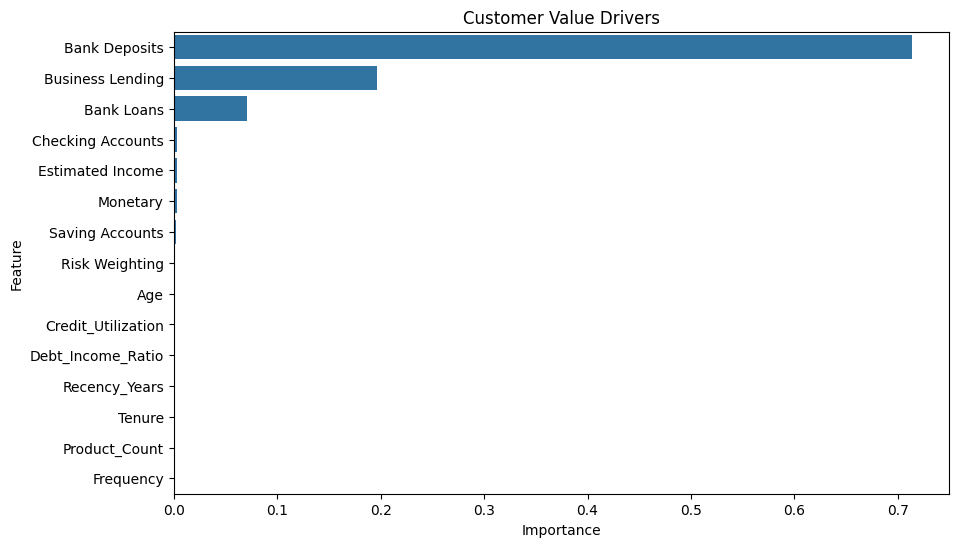

In [19]:
#Feature Importance
importance_reg = pd.DataFrame({
    "Feature": X_reg.columns,
    "Importance": rf_reg_model.feature_importances_
})

importance_reg = importance_reg.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_reg,
    x="Importance",
    y="Feature"
)

plt.title("Customer Value Drivers")

plt.show()

In [20]:
#Add predictions back to dataframe
df["Predicted_Customer_Value"] = rf_reg_model.predict(X_reg)

In [21]:
#Create Customer Tiers
df["Predicted_Value_Segment"] = pd.qcut(
    df["Predicted_Customer_Value"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)